# CDSDS 542 Sp2026 - Discussion 8: CNN

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://github.com/DL4DS/fa2026_discussions/blob/main/discussion_08.ipynb)

####  Computer vision libraries in PyTorch

| PyTorch module | What does it do? |
| ----- | ----- |
| [`torchvision`](https://pytorch.org/vision/stable/index.html) | Contains datasets, model architectures and image transformations often used for computer vision problems. |
| [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) | Here you'll find many example computer vision datasets for a range of problems from image classification, object detection, image captioning, video classification and more. It also contains [a series of base classes for making custom datasets](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets). |
| [`torchvision.models`](https://pytorch.org/vision/stable/models.html) | This module contains well-performing and commonly used computer vision model architectures implemented in PyTorch, you can use these with your own problems. |
| [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) | Often images need to be transformed (turned into numbers/processed/augmented) before being used with a model, common image transformations are found here. |
| [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Base dataset class for PyTorch.  |
| [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Creates a Python iterable over a dataset (created with `torch.utils.data.Dataset`). |    
    

In [47]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from io import BytesIO
import numpy as np
import requests

from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode

### **Exercise 1 — Basic Output Size**

A 1D convolution layer has:

* Input: 1 channel, length (6)
* Kernel size: (3)
* Stride: (1)
* Padding: (0)
* Number of output channels: (2)

**(a)** How many output values does each output channel produce?

**(b)** If channel-1’s kernel is $(w_1,w_2,w_3)$ and inputs are $x_1,\dots,x_6$, write the formula for the first output value $h_1^{(1)}$ of channel 1?


**Solution**:







---

### **Exercise 2 — Parameter Count**

A 2D convolution layer takes:

* Input: 3 channels, RGB
* Output: 16 channels
* Kernel size: $3\times3$
* Bias term per **output channel**.

Find the total number of learnable parameters (including biases).
(Hint: each output channel has 3×3×3 = 27 weights + 1 bias)

**Solution**:









---


![example of going through the different parameters of a Conv2d layer](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-conv2d-layer.gif)

*Example of what happens when you change the hyperparameters of a `nn.Conv2d()` layer.*
![title](https://ujwlkarn.files.wordpress.com/2016/07/convolution_schematic.gif)

#### Typical CNN framework
![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-07-at-4-59-29-pm.png)


In Practice a CNN will learn the values of these filters on its own, during the training process. We need to define the parameters of `nn.Conv2d()`:

* `in_channels` (int) - Number of channels in the input image.
* `out_channels` (int) - Number of channels produced by the convolution. (Number of filters)
* `kernel_size` (int or tuple) - Size of the convolving kernel/filter.
* `stride` (int or tuple, optional) - How big of a step the convolving kernel takes at a time. Default: 1.
* `padding` (int, tuple, str) - Padding added to all four sides of input. We can add extra pixels around the edges of the input image to make sure the filter properly passes over the edges of the image. A feature of zero padding is that it will allow us to control the spatial size of the output volumes. Used when its required to preserve the spatial size of the input volume so the input and output width and height are the same. Default: 0.

### Convolution Layers

In [48]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
tensor = torch.randn(1, 3, 64, 64)
output = conv_layer(tensor)
print(conv_layer)
print(output.size())
print()

conv_layer_2 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=4, stride=2, padding=1)
output_2 = conv_layer_2(tensor)
print(conv_layer_2)
print(output_2.size())

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
torch.Size([1, 16, 64, 64])

Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
torch.Size([1, 16, 32, 32])


### Pooling Layers

Pooling layer downsamples the volume spatially, independently in each depth slice of the input volume. Left: In this example, the input volume of size [224x224x64] is pooled with filter size 2, stride 2 into output volume of size [112x112x64]. Notice that the volume depth is preserved. Right: The most common downsampling operation is max, giving rise to max pooling, here shown with a stride of 2. That is, each max is taken over 4 numbers (little 2x2 square).
![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-10-at-3-38-39-am.png?w=988)

In [49]:
max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
output_3 = max_pool_layer(tensor)
print(tensor.shape)
print(max_pool_layer)
print(output_3.size())

torch.Size([1, 3, 64, 64])
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
torch.Size([1, 3, 32, 32])


The function of Pooling is to progressively reduce the spatial size of the input representation.
* It reduces the amount of parameters and computation in the network, and hence to also control overfitting.
* It makes the detection of features invariant to small transformations, distortions and translations. (a small distortion in input will not change the output of Pooling – since we take the maximum / average value in a local neighborhood).
![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-07-at-6-11-53-pm.png)

### Build a Simple CNN

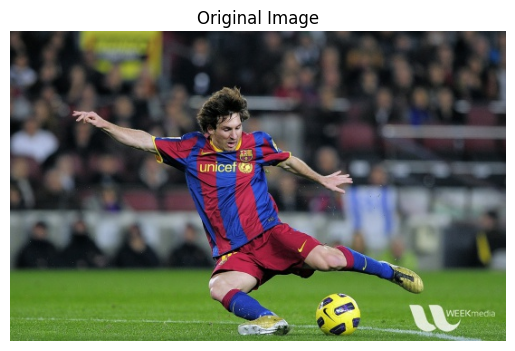

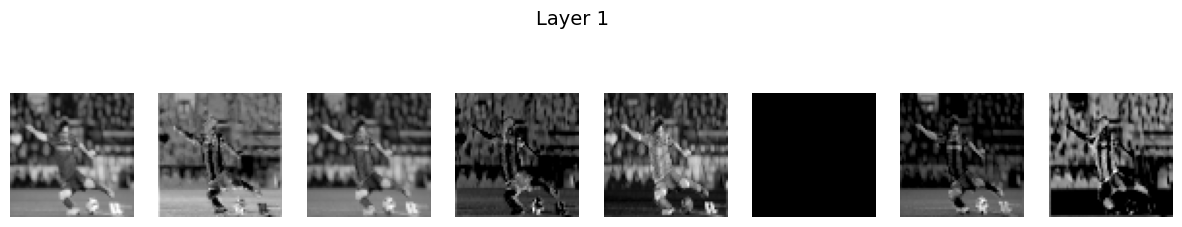

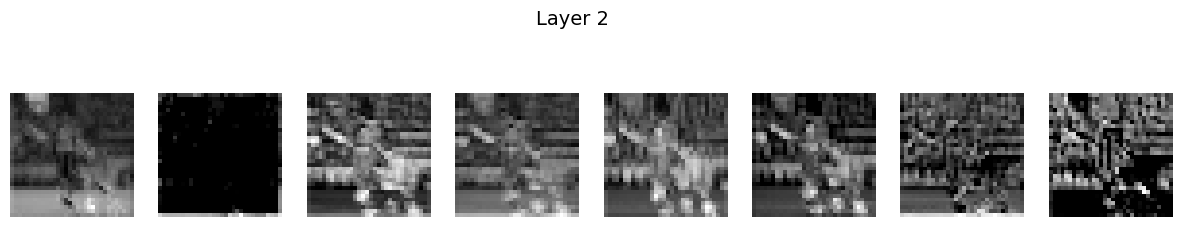

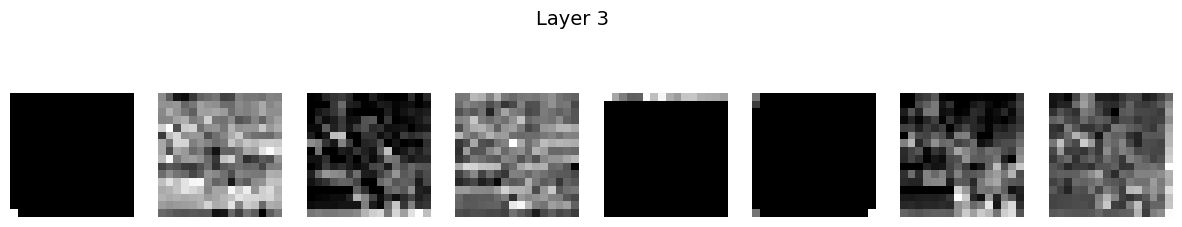

In [50]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

    def forward(self, x):
        out1 = self.layer1(x)
        out2 = self.layer2(out1)
        out3 = self.layer3(out2)
        return out1, out2, out3

# load sample image
response = requests.get("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg")
img = PILImage.open(BytesIO(response.content)).convert("RGB")
transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])
x = transform(img).unsqueeze(0)

# forward pass
model = SimpleCNN()
with torch.no_grad():
    out1, out2, out3 = model(x)

# visualize layer outputs
def visualize(tensor, title, n=8):
    tensor = tensor.squeeze(0)
    tensor = tensor.detach().cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    fig.suptitle(title, fontsize=14)
    for i in range(n):
        axes[i].imshow(tensor[i], cmap='gray')
        axes[i].axis('off')
    plt.show()


plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()
visualize(out1, "Layer 1")
visualize(out2, "Layer 2")
visualize(out3, "Layer 3")


## **Train an Object Detection Model**

#### Download Dataset
We use the Penn-Fudan pedestrian dataset, which contains images and segmentation masks for people. We will convert these masks into bounding boxes for object detection.

In [51]:
import os
import zipfile
import urllib.request

url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
zip_path = "PennFudanPed.zip"
extract_path = "."

if not os.path.exists("PennFudanPed"):
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset already exists.")

Dataset already exists.


#### Dataset Preparation
We define a custom dataset that loads images and converts segmentation masks into bounding boxes. For simplicity, we keep only the largest person in each image.

In [52]:
class PennFudanSingleBoxDataset(Dataset):
    def __init__(self, root, image_size=(128, 128)):
        self.root = root
        self.image_dir = os.path.join(root, "PNGImages")
        self.mask_dir = os.path.join(root, "PedMasks")
        self.image_files = sorted(os.listdir(self.image_dir))
        self.mask_files = sorted(os.listdir(self.mask_dir))
        self.image_size = image_size

        self.img_transform = T.Compose([
            T.Resize(image_size),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        img = PILImage.open(img_path).convert("RGB")
        mask = np.array(PILImage.open(mask_path))

        orig_w, orig_h = img.size

        # each pedestrian has a different integer ID in the mask
        obj_ids = np.unique(mask)
        obj_ids = obj_ids[obj_ids != 0]  # remove background

        boxes = []
        for obj_id in obj_ids:
            pos = np.where(mask == obj_id)
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])

        # choose largest box for simplicity
        areas = [(x2 - x1) * (y2 - y1) for x1, y1, x2, y2 in boxes]
        box = boxes[np.argmax(areas)]
        xmin, ymin, xmax, ymax = box

        # normalize to original image size
        x_center = ((xmin + xmax) / 2) / orig_w
        y_center = ((ymin + ymax) / 2) / orig_h
        width = (xmax - xmin) / orig_w
        height = (ymax - ymin) / orig_h

        target = {
            "bbox": torch.tensor([x_center, y_center, width, height], dtype=torch.float32),
            "obj": torch.tensor([1.0], dtype=torch.float32),
            "label": torch.tensor(1, dtype=torch.long)  # 1 = person
        }

        img_tensor = self.img_transform(img)
        return img_tensor, target

#### Train/Test Split
We split the dataset into training and validation sets and create DataLoaders to efficiently batch and shuffle the data during training.

In [53]:
dataset = PennFudanSingleBoxDataset("PennFudanPed", image_size=(128, 128))

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

Train size: 136
Val size: 34


#### Model Architecture
We build a small convolutional neural network that extracts image features and predicts objectness, bounding box coordinates, and class labels.

In [54]:
class DetectorModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),   # 128 -> 64

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),   # 16 -> 8

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
        )

        # keep some spatial info instead of collapsing immediately to 1x1
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1 + 4 + num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)

        obj_logit = x[:, 0:1]
        bbox_raw = x[:, 1:5]
        class_logits = x[:, 5:]

        bbox = torch.sigmoid(bbox_raw)

        return obj_logit, bbox, class_logits

#### Loss Function
The model is trained using a combination of objectness loss, bounding box regression loss, and classification loss.

In [55]:
def detection_loss(obj_logit, bbox_pred, class_logits, targets):
    target_obj = targets["obj"].to(obj_logit.device)       # [B, 1]
    target_bbox = targets["bbox"].to(obj_logit.device)     # [B, 4]
    target_label = targets["label"].to(obj_logit.device)   # [B]

    obj_loss = F.binary_cross_entropy_with_logits(obj_logit, target_obj)
    box_loss = F.smooth_l1_loss(bbox_pred, target_bbox)
    cls_loss = F.cross_entropy(class_logits, target_label)

    total = obj_loss + 5.0 * box_loss + cls_loss
    return total, obj_loss.item(), box_loss.item(), cls_loss.item()

#### Training the Model
We train the model by minimizing the detection loss over several epochs, updating the network weights using gradient descent.

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DetectorModel(num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, targets in train_loader:
        images = images.to(device)

        obj_logit, bbox_pred, class_logits = model(images)
        loss, _, _, _ = detection_loss(obj_logit, bbox_pred, class_logits, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            obj_logit, bbox_pred, class_logits = model(images)
            loss, _, _, _ = detection_loss(obj_logit, bbox_pred, class_logits, targets)
            val_loss += loss.item()

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

Epoch  1 | Train Loss: 0.2985 | Val Loss: 0.0523
Epoch  2 | Train Loss: 0.1273 | Val Loss: 0.1329
Epoch  3 | Train Loss: 0.1354 | Val Loss: 0.1189
Epoch  4 | Train Loss: 0.1394 | Val Loss: 0.0815
Epoch  5 | Train Loss: 0.0983 | Val Loss: 0.0537
Epoch  6 | Train Loss: 0.0587 | Val Loss: 0.0474
Epoch  7 | Train Loss: 0.0414 | Val Loss: 0.0347
Epoch  8 | Train Loss: 0.0288 | Val Loss: 0.0355
Epoch  9 | Train Loss: 0.0244 | Val Loss: 0.0409
Epoch 10 | Train Loss: 0.0193 | Val Loss: 0.0334
Epoch 11 | Train Loss: 0.0158 | Val Loss: 0.0281
Epoch 12 | Train Loss: 0.0144 | Val Loss: 0.0285
Epoch 13 | Train Loss: 0.0130 | Val Loss: 0.0325
Epoch 14 | Train Loss: 0.0112 | Val Loss: 0.0283
Epoch 15 | Train Loss: 0.0102 | Val Loss: 0.0272


#### Visualization Function
We define a helper function to draw predicted bounding boxes on images so we can visually evaluate model performance.

In [57]:
def draw_box(image_tensor, bbox, title=""):
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    h, w, _ = img.shape

    x_center, y_center, bw, bh = bbox
    x1 = int((x_center - bw / 2) * w)
    y1 = int((y_center - bh / 2) * h)
    x2 = int((x_center + bw / 2) * w)
    y2 = int((y_center + bh / 2) * h)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w - 1, x2)
    y2 = min(h - 1, y2)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2)
    )
    plt.title(title)
    plt.axis("off")
    plt.show()

#### Model Predictions
We run the trained model on validation images and compare predicted bounding boxes with ground truth.

Prediction 1: obj=1.000, class=1


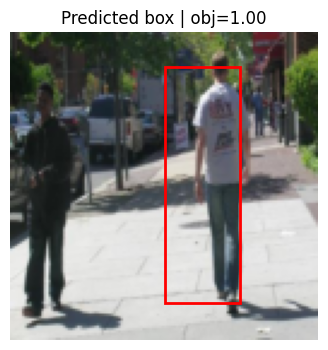

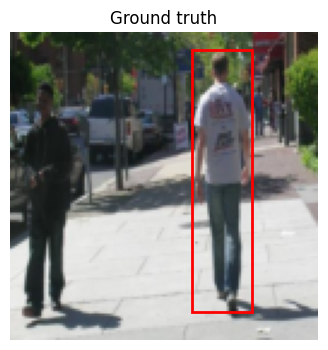

Prediction 2: obj=1.000, class=1


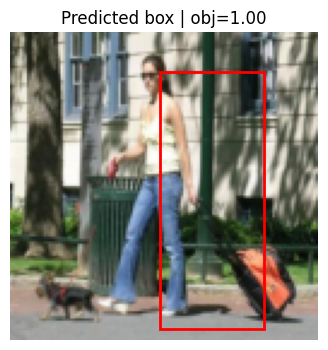

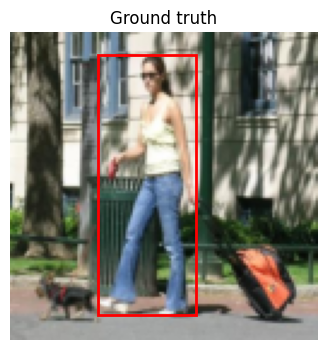

Prediction 3: obj=1.000, class=1


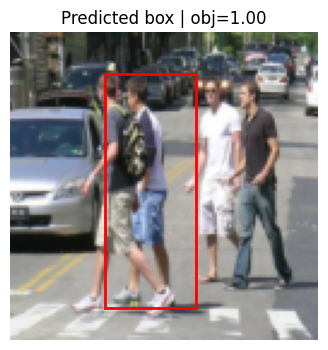

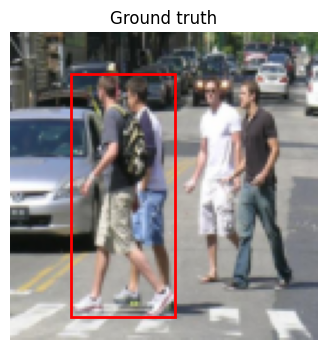

Prediction 4: obj=1.000, class=1


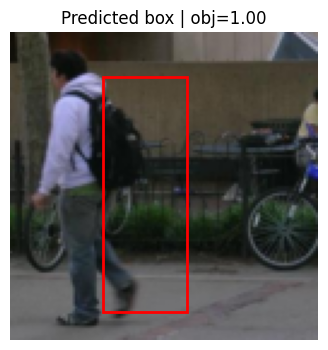

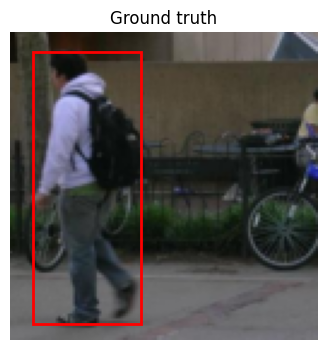

Prediction 5: obj=1.000, class=1


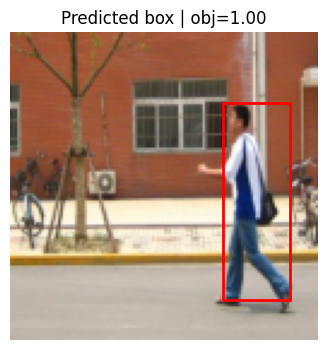

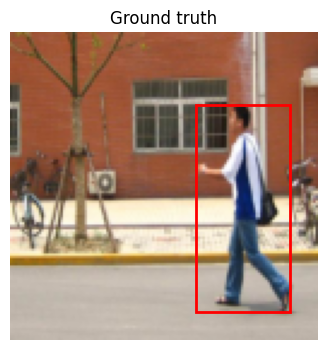

In [58]:
model.eval()

for i in range(5):
    image, target = val_ds[i]
    x = image.unsqueeze(0).to(device)

    with torch.no_grad():
        obj_logit, bbox_pred, class_logits = model(x)

    obj_score = torch.sigmoid(obj_logit)[0, 0].item()
    pred_bbox = bbox_pred[0].cpu().numpy()
    pred_class = torch.argmax(class_logits, dim=1).item()

    print(f"Prediction {i+1}: obj={obj_score:.3f}, class={pred_class}")
    draw_box(image, pred_bbox, title=f"Predicted box | obj={obj_score:.2f}")
    draw_box(image, target["bbox"].numpy(), title="Ground truth")

#### Applying the Model to a New Image
Finally, we test the model on a new image (Messi) to see how well it generalizes beyond the training dataset.

Objectness: 0.9994134902954102
Predicted class: 1


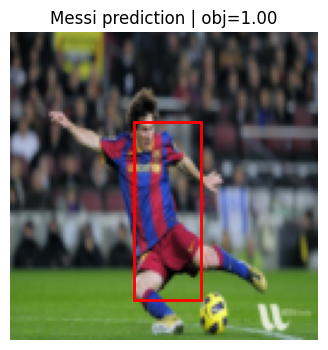

In [59]:
response = requests.get("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg")
img = PILImage.open(BytesIO(response.content)).convert("RGB")

transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])

x = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    obj_logit, bbox_pred, class_logits = model(x)

obj_score = torch.sigmoid(obj_logit)[0, 0].item()
pred_bbox = bbox_pred[0].cpu().numpy()
pred_class = torch.argmax(class_logits, dim=1).item()

print("Objectness:", obj_score)
print("Predicted class:", pred_class)

img_tensor = transform(img)
draw_box(img_tensor, pred_bbox, title=f"Messi prediction | obj={obj_score:.2f}")